
У цій роботі не реалізуються вручну методи Differential Evolution та PSO. Використовуються готові бібліотечні засоби:

- `scipy.optimize.differential_evolution` для диференціальної еволюції;
- `pyswarms.single.GlobalBestPSO` для методу рою частинок.

## 1. Імпорт бібліотек


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution
import pyswarms as ps

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.grid'] = True


## 2. Основні налаштування

In [2]:
DATA_PATH_OPTIONS = ['DataRegression.xlsx']
DATA_PATH = next((path for path in DATA_PATH_OPTIONS if Path(path).exists()), DATA_PATH_OPTIONS[0])

CHOSEN_VARIANTS = ['Var03', 'Var15', 'Var18']

TEST_SIZE = 0.25
RANDOM_STATE = 42
ROUND_DIGITS = 4

# Налаштування для готового Differential Evolution із scipy
DE_MAXITER = 10_000
DE_POPSIZE = 50
DE_TOL = 1e-10
DE_POLISH = False
DE_MUTATION = 0.8
DE_RECOMBINATION = 0.9

# Налаштування для готового PSO з pyswarms
PSO_PARTICLES = 50
PSO_ITERS = 10_000
PSO_OPTIONS = {'c1': 1.49, 'c2': 1.49, 'w': 0.72}


## 3. Моделі для варіантів

Функції нижче задають нелінійні регресійні моделі. Оптимізатори будуть підбирати параметри `b`, щоб мінімізувати похибку між реальними значеннями `y` і прогнозом моделі.

In [3]:
def safe_exp(z):
    return np.exp(np.clip(z, -700, 700))


def model_var03(x, b):
    b1, b2, b3, b4, b5, b6 = b
    return b1 * safe_exp(-b2 * x) + b3 * safe_exp(-b4 * x) + b5 * safe_exp(-b6 * x)


def model_var15(x, b):
    b1, b2, b3 = b
    return b1 / (1 + safe_exp(b2 - b3 * x))


def model_var18(x, b):
    b1, b2, b3 = b
    base = b2 + x
    if np.any(base <= 0) or abs(b3) < 1e-12:
        return np.full_like(x, np.nan, dtype=float)
    return b1 * np.power(base, -1 / b3)


MODELS = {
    'Var03': model_var03,
    'Var15': model_var15,
    'Var18': model_var18
}

## 4. Межі параметрів

Межі параметрів узято з попередньої Lab6, щоб результати нової роботи було коректно порівнювати зі старою ручною реалізацією.


In [4]:
BOUNDS = {
    # y = b1*exp(-b2*x) + b3*exp(-b4*x) + b5*exp(-b6*x)
    'Var03': [(0, 1), (0, 1), (0, 1), (0, 10), (0, 10), (0, 10)],

    # y = b1 / (1 + exp(b2 - b3*x))
    'Var15': [(50, 100), (1, 10), (0, 1)],

    # y = b1 * (b2 + x)^(-1/b3)
    'Var18': [(-10000, -1000), (1, 100), (1e-6, 1)]
}


## 5. Допоміжні функції
Функції для обчислення похибки, метрик і виведення результатів.

In [5]:
def load_variant(sheet_name):
    df = pd.read_excel(DATA_PATH, sheet_name=sheet_name).dropna()
    x = df['x'].to_numpy(dtype=float)
    y = df['y'].to_numpy(dtype=float)
    return x, y


def objective_single(b, x, y, model):
    y_pred = model(x, np.asarray(b, dtype=float))
    if not np.all(np.isfinite(y_pred)):
        return 1e100
    return np.mean((y - y_pred) ** 2)


def objective_swarm(particles, x, y, model):
    values = []
    for b in particles:
        values.append(objective_single(b, x, y, model))
    return np.array(values)


def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


def split_data(x, y):
    return train_test_split(x, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)


def rounded_array(values, digits=ROUND_DIGITS):
    return np.round(np.asarray(values, dtype=float), digits)


def rounded_table(df, digits=ROUND_DIGITS):
    table = df.copy()
    for col in table.columns:
        if col not in ['Variant', 'Method', 'Parameters', 'Old_Method']:
            table[col] = table[col].astype(float).round(digits)
    if 'Parameters' in table.columns:
        table['Parameters'] = table['Parameters'].apply(lambda p: rounded_array(p, digits))
    return table


## 6. Оптимізація через Differential Evolution

In [6]:
def run_de_for_variant(variant_name, x_train, y_train):
    model = MODELS[variant_name]
    bounds = BOUNDS[variant_name]

    result = differential_evolution(
        objective_single,
        bounds=bounds,
        args=(x_train, y_train, model),
        maxiter=DE_MAXITER,
        popsize=DE_POPSIZE,
        tol=DE_TOL,
        seed=RANDOM_STATE,
        polish=DE_POLISH,
        mutation=DE_MUTATION,
        recombination=DE_RECOMBINATION,
        updating='immediate'
    )

    return result.x, result.fun, result


## 7. Оптимізація через PSO

In [7]:
def run_pso_for_variant(variant_name, x_train, y_train):
    model = MODELS[variant_name]
    bounds = BOUNDS[variant_name]
    dimensions = len(bounds)

    lower_bounds = np.array([left for left, right in bounds], dtype=float)
    upper_bounds = np.array([right for left, right in bounds], dtype=float)

    rng = np.random.default_rng(RANDOM_STATE)
    init_pos = rng.uniform(lower_bounds, upper_bounds, size=(PSO_PARTICLES, dimensions))

    np.random.seed(RANDOM_STATE)
    optimizer = ps.single.GlobalBestPSO(
        n_particles=PSO_PARTICLES,
        dimensions=dimensions,
        options=PSO_OPTIONS,
        bounds=(lower_bounds, upper_bounds),
        init_pos=init_pos
    )

    cost, pos = optimizer.optimize(
        objective_swarm,
        iters=PSO_ITERS,
        x=x_train,
        y=y_train,
        model=model,
        verbose=False
    )

    return pos, cost, optimizer

## 8. Запуск для вибраних варіантів

In [8]:
all_results = []
all_histories = {}
all_predictions = {}

for variant_name in CHOSEN_VARIANTS:
    print(f'\n{variant_name}')

    x, y = load_variant(variant_name)
    x_train, x_test, y_train, y_test = split_data(x, y)
    model = MODELS[variant_name]

    de_params, de_train_cost, de_result = run_de_for_variant(variant_name, x_train, y_train)
    pso_params, pso_train_cost, pso_optimizer = run_pso_for_variant(variant_name, x_train, y_train)

    methods = {
        'DE scipy': de_params,
        'PSO pyswarms': pso_params
    }

    for method_name, params in methods.items():
        y_pred_train = model(x_train, params)
        y_pred_test = model(x_test, params)
        y_pred_all = model(x, params)

        train_metrics = calculate_metrics(y_train, y_pred_train)
        test_metrics = calculate_metrics(y_test, y_pred_test)
        all_metrics = calculate_metrics(y, y_pred_all)

        row = {
            'Variant': variant_name,
            'Method': method_name,
            'Parameters': params,
            'Train_MSE': train_metrics['MSE'],
            'Train_RMSE': train_metrics['RMSE'],
            'Train_MAE': train_metrics['MAE'],
            'Train_R2': train_metrics['R2'],
            'Test_MSE': test_metrics['MSE'],
            'Test_RMSE': test_metrics['RMSE'],
            'Test_MAE': test_metrics['MAE'],
            'Test_R2': test_metrics['R2'],
            'All_MSE': all_metrics['MSE'],
            'All_RMSE': all_metrics['RMSE'],
            'All_MAE': all_metrics['MAE'],
            'All_R2': all_metrics['R2']
        }
        all_results.append(row)

        all_predictions[(variant_name, method_name)] = {
            'x': x,
            'y': y,
            'params': params,
            'y_pred_all': y_pred_all
        }

    all_histories[variant_name] = {
        'DE': de_result,
        'PSO': pso_optimizer.cost_history
    }

results_df = pd.DataFrame(all_results)
rounded_table(results_df)



Var03

Var15

Var18


,Variant,Method,Parameters,Train_MSE,Train_RMSE,Train_MAE,Train_R2,Test_MSE,Test_RMSE,Test_MAE,Test_R2,All_MSE,All_RMSE,All_MAE,All_R2
0,Var03,DE scipy,"[0.1107, 1.0, 1.0, 5.5267, 1.4045, 3.472]",0.0000,0.0002,0.0002,1.0000,0.0000,0.0008,0.0005,1.0000,0.0000,0.0004,0.0003,1.0000
1,Var03,PSO pyswarms,"[0.1205, 0.9471, 0.2977, 7.9324, 2.1064, 3.9192]",0.0000,0.0009,0.0007,1.0000,0.0000,0.0046,0.0022,1.0000,0.0000,0.0024,0.0011,1.0000
2,Var15,DE scipy,"[72.7856, 2.574, 0.0659]",1.2342,1.1109,0.9786,0.9974,0.3430,0.5857,0.5020,0.9994,0.9371,0.9681,0.8197,0.9982
3,Var15,PSO pyswarms,"[72.7794, 2.574, 0.0659]",1.2342,1.1110,0.9787,0.9974,0.3428,0.5855,0.5020,0.9994,0.9371,0.9680,0.8198,0.9982
4,Var18,DE scipy,"[-2386.3597, 46.1488, 0.9419]",0.0000,0.0020,0.0013,1.0000,0.0000,0.0015,0.0011,1.0000,0.0000,0.0018,0.0013,1.0000
5,Var18,PSO pyswarms,"[-3646.5627, 50.6028, 0.8732]",0.0000,0.0020,0.0014,1.0000,0.0000,0.0014,0.0011,1.0000,0.0000,0.0019,0.0013,1.0000


## 9. Таблиця результатів у зручному вигляді

In [9]:
display_cols = [
    'Variant', 'Method', 'Parameters',
    'Train_MSE', 'Train_RMSE', 'Train_MAE', 'Train_R2',
    'Test_MSE', 'Test_RMSE', 'Test_MAE', 'Test_R2',
    'All_MSE', 'All_RMSE', 'All_MAE', 'All_R2'
]

rounded_results = rounded_table(results_df[display_cols])
rounded_results


,Variant,Method,Parameters,Train_MSE,Train_RMSE,Train_MAE,Train_R2,Test_MSE,Test_RMSE,Test_MAE,Test_R2,All_MSE,All_RMSE,All_MAE,All_R2
0,Var03,DE scipy,"[0.1107, 1.0, 1.0, 5.5267, 1.4045, 3.472]",0.0000,0.0002,0.0002,1.0000,0.0000,0.0008,0.0005,1.0000,0.0000,0.0004,0.0003,1.0000
1,Var03,PSO pyswarms,"[0.1205, 0.9471, 0.2977, 7.9324, 2.1064, 3.9192]",0.0000,0.0009,0.0007,1.0000,0.0000,0.0046,0.0022,1.0000,0.0000,0.0024,0.0011,1.0000
2,Var15,DE scipy,"[72.7856, 2.574, 0.0659]",1.2342,1.1109,0.9786,0.9974,0.3430,0.5857,0.5020,0.9994,0.9371,0.9681,0.8197,0.9982
3,Var15,PSO pyswarms,"[72.7794, 2.574, 0.0659]",1.2342,1.1110,0.9787,0.9974,0.3428,0.5855,0.5020,0.9994,0.9371,0.9680,0.8198,0.9982
4,Var18,DE scipy,"[-2386.3597, 46.1488, 0.9419]",0.0000,0.0020,0.0013,1.0000,0.0000,0.0015,0.0011,1.0000,0.0000,0.0018,0.0013,1.0000
5,Var18,PSO pyswarms,"[-3646.5627, 50.6028, 0.8732]",0.0000,0.0020,0.0014,1.0000,0.0000,0.0014,0.0011,1.0000,0.0000,0.0019,0.0013,1.0000


## 10. Графіки апроксимації

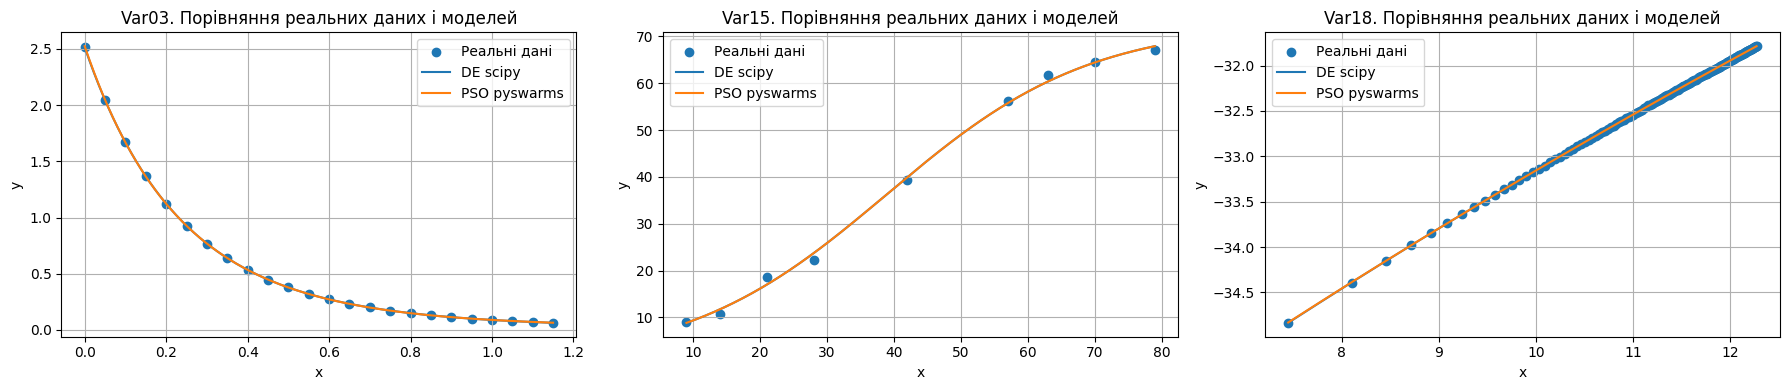

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, variant_name in zip(axes, CHOSEN_VARIANTS):
    x, y = load_variant(variant_name)
    model = MODELS[variant_name]

    x_line = np.linspace(np.min(x), np.max(x), 400)

    ax.scatter(x, y, label='Реальні дані')

    for method_name in ['DE scipy', 'PSO pyswarms']:
        params = all_predictions[(variant_name, method_name)]['params']
        y_line = model(x_line, params)
        ax.plot(x_line, y_line, label=method_name)

    ax.set_title(f'{variant_name}. Порівняння реальних даних і моделей')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## 11. Графіки збіжності PSO

Як зменшувалась похибка в процесі роботи готового PSO


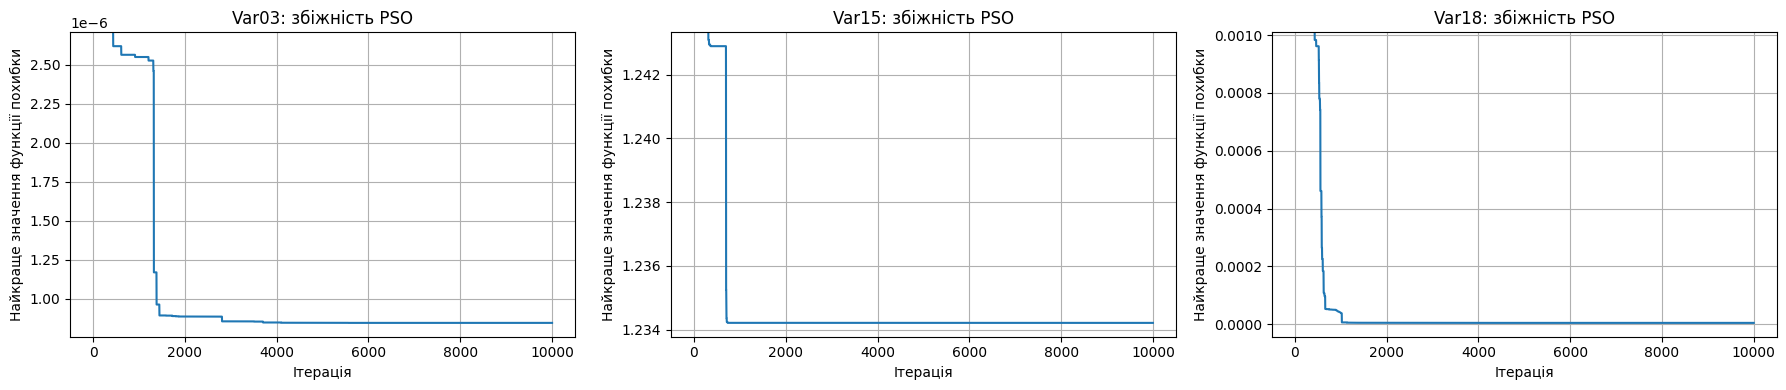

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, variant_name in zip(axes, CHOSEN_VARIANTS):
    history = np.asarray(all_histories[variant_name]['PSO'], dtype=float)
    history = history[np.isfinite(history)]

    ax.plot(history)

    if len(history) > 0:
        y_min = np.min(history)
        y_max = np.percentile(history, 95)

        if y_max > y_min:
            margin = 0.05 * (y_max - y_min)
            ax.set_ylim(y_min - margin, y_max + margin)

    ax.set_title(f'{variant_name}: збіжність PSO')
    ax.set_xlabel('Ітерація')
    ax.set_ylabel('Найкраще значення функції похибки')
    ax.grid(True)

plt.tight_layout()
plt.show()

## 12. Порівняння з лабораторною №6



In [12]:
old_results = pd.DataFrame({
    'Variant': ['Var03', 'Var03', 'Var15', 'Var15', 'Var18', 'Var18'],
    'Old_Method': ['DE', 'PSO', 'DE', 'PSO', 'DE', 'PSO'],

    'Old_Formula': [
        'y = b1 exp(-b2 x) + b3 exp(-b4 x) + b5 exp(-b6 x)',
        'y = b1 exp(-b2 x) + b3 exp(-b4 x) + b5 exp(-b6 x)',
        'y = b1 / (1 + exp(b2 - b3 x))',
        'y = b1 / (1 + exp(b2 - b3 x))',
        'y = b1 (b2 + x)^(-1/b3)',
        'y = b1 (b2 + x)^(-1/b3)'
    ],

    'Old_Params': [
        [0.111, 1.000, 1.000, 5.527, 1.405, 3.472],
        [0.122, 1.000, 0.513, 6.499, 1.883, 3.782],
        [72.790, 2.574, 0.06592],
        [72.790, 2.574, 0.06592],
        [-2386.000, 46.150, 0.9419],
        [-4338.000, 52.400, 0.8481]
    ],

    'Old_Time': [98.854, 39.689, 73.355, 24.446, 83.290, 30.216],

    'Old_Train_MSE': [0.000, 0.000, 1.234, 1.234, 0.000, 0.000],
    'Old_Test_MSE':  [0.000, 0.000, 0.343, 0.343, 0.000, 0.000],

    'Old_Train_RMSE': [0.000, 0.000, 1.111, 1.111, 0.002, 0.002],
    'Old_Test_RMSE':  [0.001, 0.002, 0.586, 0.586, 0.001, 0.001],

    'Old_Train_MAE': [0.000, 0.000, 0.979, 0.979, 0.001, 0.001],
    'Old_Test_MAE':  [0.000, 0.001, 0.502, 0.502, 0.001, 0.001],

    'Old_Train_R2': [1.000, 1.000, 0.997, 0.997, 1.000, 1.000],
    'Old_Test_R2':  [1.000, 1.000, 0.999, 0.999, 1.000, 1.000]
})
new_results = rounded_results.copy()

new_results['Old_Method'] = new_results['Method'].replace({
    'DE scipy': 'DE',
    'PSO pyswarms': 'PSO'
})

comparison = new_results.merge(
    old_results,
    on=['Variant', 'Old_Method'],
    how='left'
)

comparison['Diff_Test_MSE'] = comparison['Test_MSE'] - comparison['Old_Test_MSE']
comparison['Diff_Test_RMSE'] = comparison['Test_RMSE'] - comparison['Old_Test_RMSE']
comparison['Diff_Test_MAE'] = comparison['Test_MAE'] - comparison['Old_Test_MAE']
comparison['Diff_Test_R2'] = comparison['Test_R2'] - comparison['Old_Test_R2']

metrics_table = comparison[[
    'Variant', 'Method',
    'Test_MSE', 'Old_Test_MSE',
    'Test_RMSE', 'Old_Test_RMSE',
    'Test_MAE', 'Old_Test_MAE',
    'Test_R2', 'Old_Test_R2'
]]

diff_table = comparison[[
    'Variant', 'Method',
    'Diff_Test_MSE',
    'Diff_Test_RMSE',
    'Diff_Test_MAE',
    'Diff_Test_R2'
]]

print('Таблиця 1. Порівняння нових і старих результатів')
display(rounded_table(metrics_table))

print('Таблиця 2. Різниця між новими і старими результатами')
display(rounded_table(diff_table))

Таблиця 1. Порівняння нових і старих результатів


,Variant,Method,Test_MSE,Old_Test_MSE,Test_RMSE,Old_Test_RMSE,Test_MAE,Old_Test_MAE,Test_R2,Old_Test_R2
0,Var03,DE scipy,0.0000,0.000,0.0008,0.001,0.0005,0.000,1.0000,1.000
1,Var03,PSO pyswarms,0.0000,0.000,0.0046,0.002,0.0022,0.001,1.0000,1.000
2,Var15,DE scipy,0.3430,0.343,0.5857,0.586,0.5020,0.502,0.9994,0.999
3,Var15,PSO pyswarms,0.3428,0.343,0.5855,0.586,0.5020,0.502,0.9994,0.999
4,Var18,DE scipy,0.0000,0.000,0.0015,0.001,0.0011,0.001,1.0000,1.000
5,Var18,PSO pyswarms,0.0000,0.000,0.0014,0.001,0.0011,0.001,1.0000,1.000


Таблиця 2. Різниця між новими і старими результатами


,Variant,Method,Diff_Test_MSE,Diff_Test_RMSE,Diff_Test_MAE,Diff_Test_R2
0,Var03,DE scipy,0.0000,-0.0002,0.0005,0.0000
1,Var03,PSO pyswarms,0.0000,0.0026,0.0012,0.0000
2,Var15,DE scipy,0.0000,-0.0003,0.0000,0.0004
3,Var15,PSO pyswarms,-0.0002,-0.0005,0.0000,0.0004
4,Var18,DE scipy,0.0000,0.0005,0.0001,0.0000
5,Var18,PSO pyswarms,0.0000,0.0004,0.0001,0.0000
